In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy import signal as sg
from numba import jit


### Helper functions

In [2]:
def readbinary_dat(file):
    with open(file, "rb") as f:
        # Binary file is organized as 1 sleep/wake score, 401 spectral bins
        # (0-100Hz at 0.25Hz resolution, EEG variance, EMG variance, temperature
        # (note that this value will be empty if no temperature was recorded).
        tempscores = []
        temppowspec = np.zeros((401, 86400), dtype=np.float32)
        EEG_variance = np.zeros((86400,), dtype=np.float32)
        EMG_variance = np.zeros((86400,), dtype=np.float32)
        Temperature = np.zeros((86400,), dtype=np.float32)

        for T in range(86400):
            # read sleep/wake scores
            tempscores.append(f.read(1).decode('utf-8'))
            
            # read power spectra
            temppowspec[:, T] = np.fromfile(f, dtype=np.float32, count=401)
            
            # read EEG variance, EMG variance, and cortical temperature into temporary block
            misctemp = np.fromfile(f, dtype=np.float32, count=3)
            
            # extract EEG variance, EMG variance, and Temperature
            EEG_variance[T] = misctemp[0]
            EMG_variance[T] = misctemp[1]
            Temperature[T] = misctemp[2]

        # convert to character array
        sleep_wake_scores = ''.join(tempscores)
        
        # transpose power spectra matrix into array of 86400*401 values (values are given in volts^2/0.25Hz)
        power_spectra = temppowspec.T
        
        # remove temperature data if it does not exist
        if Temperature[0] == 0:
            Temperature = np.array([])

    return sleep_wake_scores, power_spectra, EEG_variance, EMG_variance, Temperature


def readbinary_EEG(file):
    with open(file, "rb") as f:
        # Binary file is a single vector of EEG data, sampled at 200Hz for a total
        # of 69,120,000 values given in volts
        raw_EEG = np.fromfile(f, dtype=np.float32, count=-1)

    return raw_EEG

## Preliminary data exploration shenanigans

In [3]:
sleep_wake_scores, power_spectra, EEG_variance, EMG_variance, Temperature = readbinary_dat('/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M1EXP1/M1EXP1.dat')

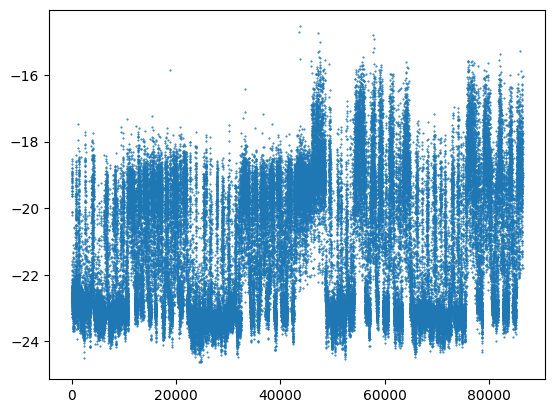

In [4]:
plt.plot(np.log(EMG_variance),'.',markersize=1)

In [5]:
sleep_wake_scores = sleep_wake_scores.replace('w','1')
sleep_wake_scores = sleep_wake_scores.replace('n','2')
sleep_wake_scores = sleep_wake_scores.replace('r','3')
sws = [int(c) for c in sleep_wake_scores]

In [6]:
print(np.sum([s==1 for s in sws]), np.sum([s==2 for s in sws]),np.sum([s==3 for s in sws]))

49696 32368 4336


(array([0.01536451, 0.09218795, 0.3510199 , 0.69613038, 1.03297776,
        1.02942201, 0.79659062, 0.51294319, 0.31792712, 0.15010089,
        0.07327688, 0.03072902, 0.00945517, 0.00472754, 0.00354566,
        0.        , 0.00354566, 0.00236377, 0.0011819 , 0.00118189]),
 array([-24.6187706 , -24.42363548, -24.22850227, -24.03336716,
        -23.83823204, -23.64309883, -23.44796371, -23.2528286 ,
        -23.05769539, -22.86256027, -22.66742706, -22.47229195,
        -22.27715683, -22.08202362, -21.8868885 , -21.69175339,
        -21.49662018, -21.30148506, -21.10634995, -20.91121674,
        -20.71608162]),
 <BarContainer object of 20 artists>)

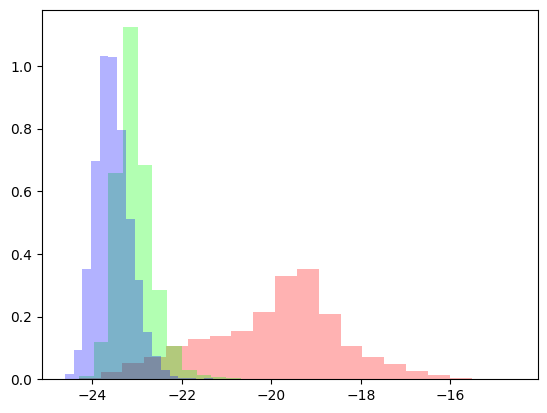

In [7]:
EMGv1 = EMG_variance[np.array(sws)==1]
EMGv2 = EMG_variance[np.array(sws)==2]
EMGv3 = EMG_variance[np.array(sws)==3]
plt.hist(np.log(EMGv1),bins=20,alpha=.3,density=True,color=(1,0,0))
plt.hist(np.log(EMGv2),bins=20,alpha=.3,density=True,color=(0,1,0))
plt.hist(np.log(EMGv3),bins=20,alpha=.3,density=True,color=(0,0,1))

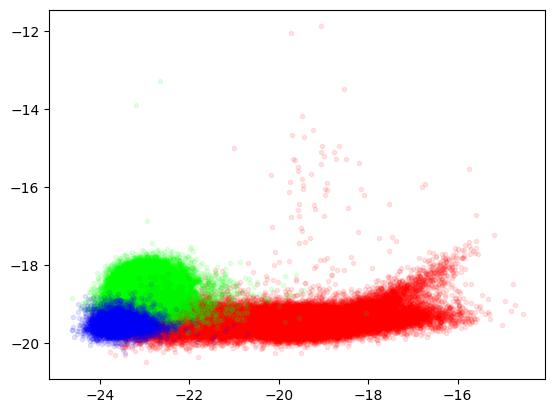

In [8]:
%matplotlib inline
EEG_EMGv1 = np.array([EMG_variance[np.array(sws)==1],EEG_variance[np.array(sws)==1]])
EEG_EMGv2 = np.array([EMG_variance[np.array(sws)==2],EEG_variance[np.array(sws)==2]])
EEG_EMGv3 = np.array([EMG_variance[np.array(sws)==3],EEG_variance[np.array(sws)==3]])
plt.figure()
plt.plot(np.log(EEG_EMGv1[0,:]),np.log(EEG_EMGv1[1,:]),'.',alpha=.1,color=(1,0,0))
plt.plot(np.log(EEG_EMGv2[0,:]),np.log(EEG_EMGv2[1,:]),'.',alpha=.1,color=(0,1,0))
plt.plot(np.log(EEG_EMGv3[0,:]),np.log(EEG_EMGv3[1,:]),'.',alpha=.1,color=(0,0,1))

<IPython.core.display.Javascript object>


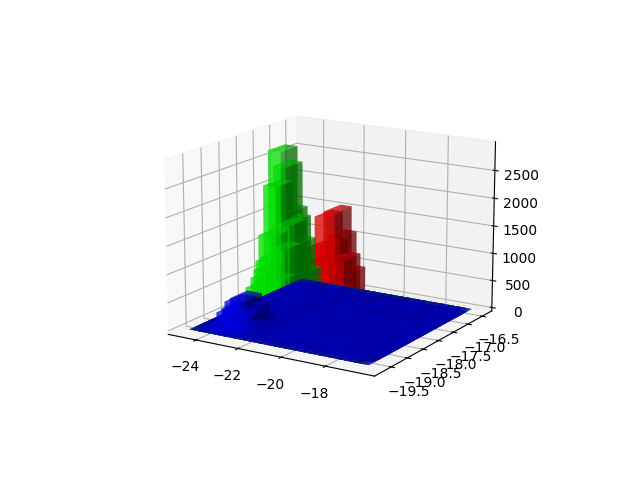

In [20]:
%matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

hist1, xedges, yedges = np.histogram2d(np.log(EEG_EMGv1[0,:]),np.log(EEG_EMGv1[1,:]), bins=20, range=[[-25, -17], [-20, -17]])
hist2, xedges, yedges = np.histogram2d(np.log(EEG_EMGv2[0,:]),np.log(EEG_EMGv2[1,:]), bins=20, range=[[-25, -17], [-20, -17]])
hist3, xedges, yedges = np.histogram2d(np.log(EEG_EMGv3[0,:]),np.log(EEG_EMGv3[1,:]), bins=20, range=[[-25, -17], [-20, -17]])

# Construct arrays for the anchor positions of the 16 bars.
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.5 * np.ones_like(zpos)
dz1 = hist1.ravel()
dz2 = hist2.ravel()
dz3 = hist3.ravel()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz1, zsort='average', alpha=0.5, color=[1,0,0])
ax.bar3d(xpos, ypos, zpos, dx+.1, dy, dz2, zsort='average', alpha=0.5, color=[0,1,0])
ax.bar3d(xpos, ypos, zpos, dx+.2, dy, dz3, zsort='average', alpha=0.5, color=[0,0,1])

plt.show()

In [21]:
raw_EEG = readbinary_EEG('/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M1EXP1/M1EXP1.eeg')

<IPython.core.display.Javascript object>


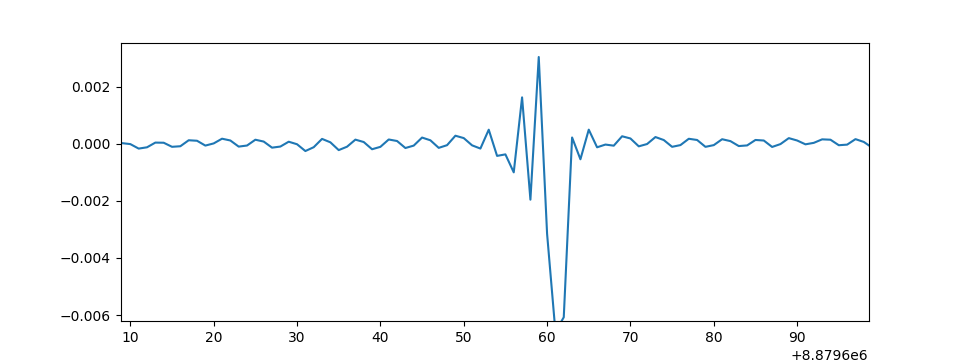

In [23]:
%matplotlib notebook
plt.figure()
plt.plot(raw_EEG)

In [20]:
raw_EEG.shape[0],EMG_variance.shape[0]

(69120000, 86400)

In [21]:
raw_EEG.shape[0]/EMG_variance.shape[0]

800.0

## Reshape data directories to use in PyEcog

In [41]:
from glob import glob
import os
import shutil
import json
from datetime import datetime

In [42]:
file_list  = glob('/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/*/*.eeg')
print(file_list)

['/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M13EXP1/M13EXP1.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M24EXP1/M24EXP1.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M7EXP1/M7EXP1.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M21EXP1/M21EXP1.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M9EXP2/M9EXP2.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M8EXP1/M8EXP1.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M5EXP2/M5EXP2.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M7EXP2/M7EXP2.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M8EXP2/M8EXP2.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M19EXP1/M19EXP1.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M11EXP1/M11EXP1.eeg', '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/M14EXP1/M14EXP1.eeg', '/h

### Rename files and create single directories for each animal

In [43]:
for fname in file_list:
    dat_fname = fname.replace('.eeg','.dat')
    dir_fname = fname.replace('.eeg','')
    (d,f) = os.path.split(dir_fname)
    new_dir = os.path.join(os.path.split(d)[0],f)
    new_fname = fname.replace(d,new_dir)
    new_datfname =dat_fname.replace(d,new_dir)
    try:
        os.mkdir(new_dir)
    except FileExistsError:
        print('Directory already exists')
        pass
    os.rename(dat_fname,new_datfname)
    os.rename(fname,new_fname)

In [44]:
file_list  = glob('/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/*/*.eeg')

#### Use path for metadata file sent in email

In [45]:
# can't remember if this is suposed to work on first run....
# ok I think this is just to grab a template for the metadata file, so use the path  for the metadata file that I sent you
with open(file_list[0]) as f:
    mdata = json.load(f)

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 0: invalid start byte

In [46]:
mdata

NameError: name 'mdata' is not defined

### Generate metadata files for the EEG, so that it can be opened in PyEcog

In [47]:
file_list  = glob('/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/*/*.eeg')
for fname in file_list:
    mdata['binaryfilename'] = fname
    mdata['start_timestamp_unix'] = int(datetime(2023,1,1,7,0,0).timestamp())
    mdata['duration'] = 3600*96
    with open(fname.replace('.eeg','.meta'),'w') as json_file:
        json.dump(mdata,json_file, indent=2, sort_keys=True)

### some tests recovering the original labels

In [48]:
file_list  = glob('/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/*/*.dat')

In [49]:
sleep_wake_scores, power_spectra, EEG_variance, EMG_variance, Temperature = readbinary_dat(file_list[0])

In [50]:
sleep_wake_scores

'...'

In [51]:
a = np.frombuffer(sleep_wake_scores.encode(),dtype='uint8')

In [52]:
da = np.diff(a,prepend=0)
transitions  = np.nonzero(da)[0]

In [53]:
len(transitions)

5053

In [54]:
sleep_wake_scores[transitions[0]]

'n'

In [55]:
def generate_event_list(event_string):
    file_start_timestamp = datetime(2023,1,1,7,0,0).timestamp()

## Manualy create a project in PyEcog GUI

I think at this point you will need to open PyEcog GUI and create a project. If everything worked fine it should be just "Project->Edit Project settings" and in that window click "select EEG root directory", choose the directory that contains the subfolders for each animal, and everything should be generated just fine. Save the project with "Project->Save Project as..."

## Add the original annotations to the PyEcog project

In [56]:
import os
import glob
import pyecog2 as pe
from pyecog2.ProjectClass import Project, FileBuffer, MainModel
from pyecog2.annotations_module import AnnotationElement
import numpy as np
from datetime import datetime

In [61]:
project_file = '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/SleepData.pyecog'
main_model = MainModel()
project=Project(main_model=main_model)
project.load_from_json(project_file)

('/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare',
 '/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare')

In [62]:
for animal in project.animal_list:
    print(f'Processing animal {animal.id}')
    file_init_time = animal.eeg_init_time[0]
    datfile = animal.eeg_files[0].replace('.meta', '.dat')
    sleep_wake_scores, power_spectra, EEG_variance, EMG_variance, Temperature = readbinary_dat(datfile)
    sleep_wake_scores = sleep_wake_scores.replace('1','w')
    sleep_wake_scores = sleep_wake_scores.replace('2','n')
    sleep_wake_scores = sleep_wake_scores.replace('3','r')
    a = np.frombuffer(sleep_wake_scores.encode(),dtype='uint8')
    da = np.diff(a,prepend=0)
    transitions  = np.nonzero(da)[0]
    N = len(transitions)
    for i,t in enumerate(transitions):
        print(f'{i} out of {N}',end='\r')
        label = sleep_wake_scores[t]
        if label == 'w':
            continue
        start = t*4+ file_init_time
        if i<N-1:
              end = transitions[i+1]*4+ file_init_time
        else:
              end = len(a)*4 + file_init_time
        
        animal.annotations.add_annotation(
            AnnotationElement(label = label,
                          start = start,
                          end = end
                         ))
print('done')

Processing animal M10EXP1
Processing animal M11EXP1
Processing animal M12EXP1
Processing animal M13EXP1
Processing animal M14EXP1
Processing animal M15EXP1
Processing animal M16EXP1
Processing animal M17EXP1
Processing animal M18EXP1
Processing animal M19EXP1
Processing animal M1EXP1
Processing animal M1EXP2
Processing animal M20EXP1
Processing animal M21EXP1
Processing animal M22EXP1
Processing animal M23EXP1
Processing animal M24EXP1
Processing animal M25EXP1
Processing animal M26EXP1
Processing animal M27EXP1
Processing animal M28EXP1
Processing animal M29EXP1
Processing animal M2EXP1
Processing animal M2EXP2
Processing animal M3EXP2
Processing animal M4EXP1
Processing animal M4EXP2
Processing animal M5EXP1
Processing animal M5EXP2
Processing animal M6EXP1
Processing animal M6EXP2
Processing animal M7EXP1
Processing animal M7EXP2
Processing animal M8EXP1
Processing animal M8EXP2
Processing animal M9EXP1
Processing animal M9EXP2
done out of 5442


In [63]:
project.save_to_json('/home/mfpleite/Documents/pyecog_sleep_data/SleepDataFigShare/SleepData_annotated_3labels.pyecog')

Rubish

In [106]:
file_init_time = animal.eeg_init_time[0]
datfile = animal.eeg_files[0].replace('.meta', '.dat')
sleep_wake_scores, power_spectra, EEG_variance, EMG_variance, Temperature = readbinary_dat(datfile)
a = np.frombuffer(sleep_wake_scores.encode(),dtype='uint8')
da = np.diff(a,prepend=0)
transitions  = np.nonzero(da)[0]
N = len(transitions)

In [114]:
i = 1
t = transitions[i]

In [117]:
label = sleep_wake_scores[t]
if label == 'w':
    print('w')
start = t*4+ file_init_time
if i<N:
      end = transitions[i+1]*4+ file_init_time
else:
      end = N*4 + file_init_time
print(i,label,transitions[i],transitions[i+1],start,end)

1 n 3 16 1672556412 1672556464


In [113]:
a

'...'